<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/stacking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("sivanarayanamuppidi/wine-quality-dataset")

100%|██████████| 98.0k/98.0k [00:00<00:00, 344kB/s]

Extracting files...


In [2]:
import pandas as pd
import os

# List files in the downloaded path to find the CSV file
file_list = os.listdir(path)
csv_file = [f for f in file_list if f.endswith('.csv')][0]

# Construct the full path to the CSV file
csv_path = os.path.join(path, csv_file)

# Load the CSV into a pandas DataFrame
df = pd.read_csv(csv_path)

In [3]:
# Display the first 5 rows of the DataFrame
display(df.head())

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [5]:
print(f"DataFrame shape: {df.shape}")
df.info()

DataFrame shape: (6497, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [6]:
df.isnull().sum()

,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [7]:
import numpy as np

# Identify numerical columns with missing values
numerical_cols_with_nan = df.select_dtypes(include=np.number).columns[df.select_dtypes(include=np.number).isnull().any()].tolist()

# Impute missing values with the mean and convert to integer
for col in numerical_cols_with_nan:
    mean_value = df[col].mean()
    df[col] = df[col].fillna(mean_value)
    # Convert to integer. This will truncate decimal parts.
    df[col] = df[col].astype(int)

print("DataFrame Info after imputation and type conversion:")
df.info()
print("\nMissing values after imputation:")
print(df.isnull().sum())

DataFrame Info after imputation and type conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6497 non-null   int64  
 2   volatile acidity      6497 non-null   int64  
 3   citric acid           6497 non-null   int64  
 4   residual sugar        6497 non-null   int64  
 5   chlorides             6497 non-null   int64  
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   int64  
 10  sulphates             6497 non-null   int64  
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 660.0+ KB

Missing va

/tmp/ipykernel_5718/722177927.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


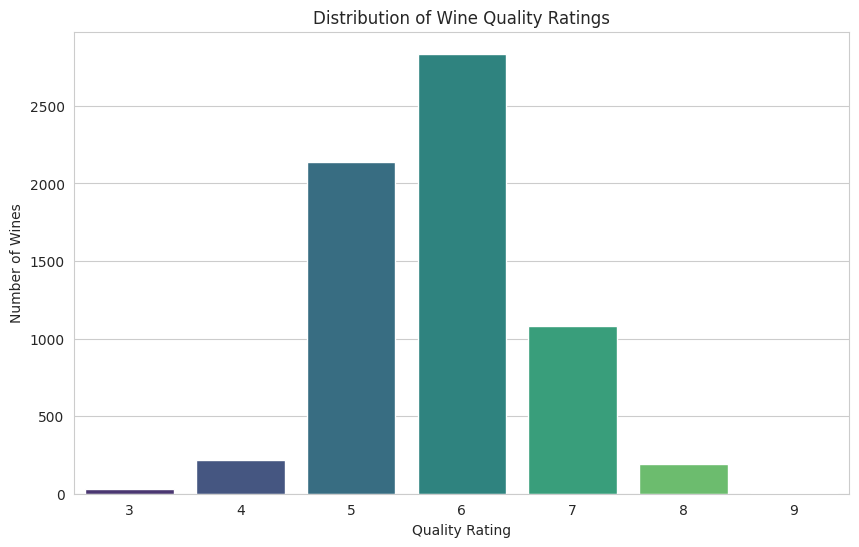

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a count plot for the 'quality' column
plt.figure(figsize=(10, 6))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Distribution of Wine Quality Ratings')
plt.xlabel('Quality Rating')
plt.ylabel('Number of Wines')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Drop the 'type' column as it's categorical. For simplicity, we'll start with numerical features.
X = df.drop(['quality', 'type'], axis=1)
y = df['quality']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define base models for stacking, wrapped in pipelines with a StandardScaler
estimators = [
    ('lr', Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])),
    ('knn', Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier())
    ])),
    ('dt', DecisionTreeClassifier(random_state=42)) # Decision tree is not sensitive to scaling
]

# Define the stacking classifier
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=2000, random_state=42)) # Increased max_iter for final estimator
    ]),
    cv=5 # Use 5-fold cross-validation for stacking
)

print("Training the Stacking Ensemble Model with Scaled Data...")
# Train the stacking model
stacking_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_stacking = stacking_model.predict(X_test)

# Evaluate the stacking model
print(f"\nStacking Ensemble Model Accuracy: {accuracy_score(y_test, y_pred_stacking):.4f}")
print("\nStacking Ensemble Model Classification Report:")
print(classification_report(y_test, y_pred_stacking))

Training the Stacking Ensemble Model with Scaled Data...

Stacking Ensemble Model Accuracy: 0.6308

Stacking Ensemble Model Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.33      0.07      0.11        46
           5       0.67      0.70      0.69       420
           6       0.61      0.72      0.66       579
           7       0.63      0.45      0.53       221
           8       0.41      0.22      0.29        32

    accuracy                           0.63      1300
   macro avg       0.44      0.36      0.38      1300
weighted avg       0.62      0.63      0.62      1300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
